In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [47]:
city = pd.read_csv('city_day.csv')
crop = pd.read_csv('crop_production.csv') 

<b>Reading the dataset and converting the dataset into a dataframe</b>

In [48]:
print("City DataFrame:")
print(city.head())

print("\nCrop DataFrame:")
print(crop.head())

City DataFrame:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Crop DataFrame:
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman a

<b>Printing First 5 observations of city and crop dataset</b>

<b>Task 1</b>

In [49]:
print("City")
print("Size: ", city.shape)
print("\n")
print("Columns: ", city.columns)
print("\n")
print("Columns Types: ")
print(city.dtypes)
print("\n")
print(city.describe())
print("\n")
print(city.info())
print("\n")
print("Null values in City DataFrame: ")
print(city.isnull().sum())
print("\n")
print("Duplicates in City DataFrame: ")
print(city.duplicated().sum())
print("\n")
city_pct = (city.isnull().sum() / len(city) * 100).round(2)
null_df = pd.DataFrame({'Missing Count': city.isnull().sum(), 'Missing %': city_pct})
print(null_df[null_df['Missing Count'] > 0])

City
Size:  (29531, 16)


Columns:  Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')


Columns Types: 
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.8

<b>Inference:</b><br>
<b>The City dataset contain 29531 observations and 16 attributes</b><br>
<b>The Colums with null values are</b><br>
PM2.5 = 4598<br>
PM10 = 11140<br>
NO = 3582<br>
NO2 = 3585<br>
NOx = 4185<br>
NH3 = 10328<br>
CO = 2059<br>
SO2 = 3854<br>
O3 = 4022<br>
Benzene = 5623<br>
Toluene = 8041<br>
Xylene = 18109<br>
AQI = 4681<br>
AQI_Bucket = 4681<br>
<b>The City dataset does not contain any duplicate values</b><br>

Xylene is missing 61.32% values which should be dropped as a modelling feature.<br>

AQI and AQI_Bucket both are missing 15.85% combined values which is a core feature and can not be filled by itself<br>

PM10 is missing 37.72% of null values.<br>

Date is stored as object that must be converted into DateTime before any time series analysis.<br>

Max Value of AQI is 2049 which is impossible because max value of AQI can be 500 leading to a data error<br>

In [50]:
print("Crop\n")
print("Size: \n", crop.shape)
print("Columns: \n", crop.columns)
print("\n")
print("Columns Types: ")
print(crop.dtypes)
print("\n")
print(crop.describe())
print("\n")
print(crop.info())
print("\n")
print("Null values in Crop DataFrame: ")
print(crop.isnull().sum())
print("\n")
print("Duplicates in Crop DataFrame: ")
print(crop.duplicated().sum())

crop_pct = (crop.isnull().sum() / len(crop) * 100).round(2)
null_df_crop = pd.DataFrame({'Missing Count': crop.isnull().sum(), 'Missing %': crop_pct})
print(null_df_crop[null_df_crop['Missing Count'] > 0])

print(sorted(crop['State_Name'].unique()))

Crop

Size: 
 (246091, 7)
Columns: 
 Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')


Columns Types: 
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


           Crop_Year          Area    Production
count  246091.000000  2.460910e+05  2.423610e+05
mean     2005.643018  1.200282e+04  5.825034e+05
std         4.952164  5.052340e+04  1.706581e+07
min      1997.000000  4.000000e-02  0.000000e+00
25%      2002.000000  8.000000e+01  8.800000e+01
50%      2006.000000  5.820000e+02  7.290000e+02
75%      2010.000000  4.392000e+03  7.023000e+03
max      2015.000000  8.580100e+06  1.250800e+09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         -------------- 

<b>Inference:</b><br>
<b>The Crop dataset contain 246091 observations and 7 attributes</b><br>
<b>The Colums with null values are</b><br>
Production = 3730<br>
<b>The Crop dataset does not contain any duplicate values</b><br>
Production is missing 1.5% it ca be filled with median by crop type<br>

<b>Task 2</b>

In [51]:
print("Null values in City Dataset: ")
print(city.isnull().sum())
print("\n")

city_clean = city.copy()

city_clean = city_clean.drop(columns = ['Xylene', 'AQI_Bucket'])

cols = ['AQI', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
        'NH3', 'CO', 'SO2', 'O3',
        'Benzene', 'Toluene']

for col in cols:
    city_clean[col] = city_clean.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )

    city_clean[col] = city_clean[col].fillna(
        city_clean[col].median()
    )

print(city_clean.isnull().sum())

city_clean['Date'] = pd.to_datetime(city_clean['Date'], errors='coerce')

Null values in City Dataset: 
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


City       0
Date       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
AQI        0
dtype: int64


PM2.5 filled with median group by city because median is robust to extremes<br>
PM10 filled with median group by city because PM10 is important feature and dropping it will loose too much data<br>
NO, NO2, NOx filled with median group by city as they are correlated<br>
NH3 filled with median group by city as dropping will loose 35% of the observations<br>
CO filled with median group by city<br>
SO2, Benzene, Toluene and O3 filled with median as mean > median which states that there are high outliers in the datasets and medan is robust to extreme outliers<br>
Xylene missing 60% of the values filling those null values can lead inconsistent dataset so that column is dropped<br>
AQI is filled with median by city as different city has different AQI<br>
AQI_Bucket is categorical column which can not be dropped. 

In [52]:
print("Null values in Crop Dataset: ")
print(crop.isnull().sum())
print("\n")

crop_clean = crop.copy()

crop_clean['Production'] = crop_clean.groupby(['Crop', 'Season'])['Production'].transform(
    lambda x: x.fillna(x.median())
)

crop_clean['Production'] = crop_clean['Production'].fillna(crop_clean['Production'].median())

print('Null values in Crop Dataset After Cleaning:')
print(crop_clean.isnull().sum())

Null values in Crop Dataset: 
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


Null values in Crop Dataset After Cleaning:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


Production is filled with median group by crop and season before taking the 
median because different crops in different seasons produce very different quantitie

<b>Task 3</b>

A merge() in pandas uses exact string matching. 'Tamil Nadu' and 'Tamil Nadu ' (trailing space) are treated as different keys. The merge drops all rows from the right dataframe that carry the space producing incorrect NaN filled rows or missing data with no error message.<br>


Strip whitespace from all state-name columns in both files<br>
Title case normalisation to catch capitalisation variants<br>
Map known old names (eg. 'Orissa' to 'Odisha', 'Uttaranchal' to 'Uttarakhand')<br>
Build a city to state lookup for the city file<br>

In [ ]:
crop_merge = crop_clean.copy()
city_merge = city_clean.copy()


print("Crop states with leading/trailing spaces:")
space_states = [s for s in crop_merge['State_Name'].unique()
                if s != s.strip()]
print(space_states)

crop_merge['State_Name'] = crop_merge['State_Name'].str.strip().str.title()

state_rename_map = {
    'Orissa': 'Odisha',
    'Uttaranchal': 'Uttarakhand',
    'Pondicherry': 'Puducherry'
}

crop_merge['State_Name'] = crop_merge['State_Name'].replace(state_rename_map)

c_to_s = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh', 'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh', 'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi', 'Ernakulam': 'Kerala', 'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana', 'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala', 'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Patna': 'Bihar',
    'Shillong': 'Meghalaya', 'Talcher': 'Odisha', 'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

city_merge['State'] = city_merge['City'].map(c_to_s)

print("Cities without state mapping:")
print(city_merge[city_merge['State'].isna()]['City'].unique())

crop_before = len(crop_merge)
crop_merge = crop_merge.drop_duplicates()
crop_after = len(crop_merge)

city_before = len(city_merge)
city_merge = city_merge.drop_duplicates()
city_after = len(city_merge)

print(f"Crop records: {crop_before} -> {crop_after}")
print(f"City records: {city_before} -> {city_after}")

Crop states with leading/trailing spaces:
['Jammu and Kashmir ', 'Telangana ']
Cities without state mapping:
[]
Crop records: 246091 -> 246091
City records: 29531 -> 29531


In [54]:
print("Unique states consistency check")

print("\nStates in City Dataset:")
print(sorted(city_merge['State'].dropna().unique()))

print("\nStates in Crop Dataset:")
print(sorted(crop_merge['State_Name'].dropna().unique()))

city_states = set(city_merge['State'].dropna().unique())
crop_states = set(crop_merge['State_Name'].dropna().unique())

overlap = city_states & crop_states

print(f"\nStates common to both files: {len(overlap)}")
print(sorted(overlap))

print("\nCity states NOT in crop file:")
print(sorted(city_states - crop_states))

print("\nCrop states NOT in city file:")
print(sorted(crop_states - city_states))

Unique states consistency check

States in City Dataset:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

States in Crop Dataset:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

States common to both files: 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Me

<b>Task 4</b>

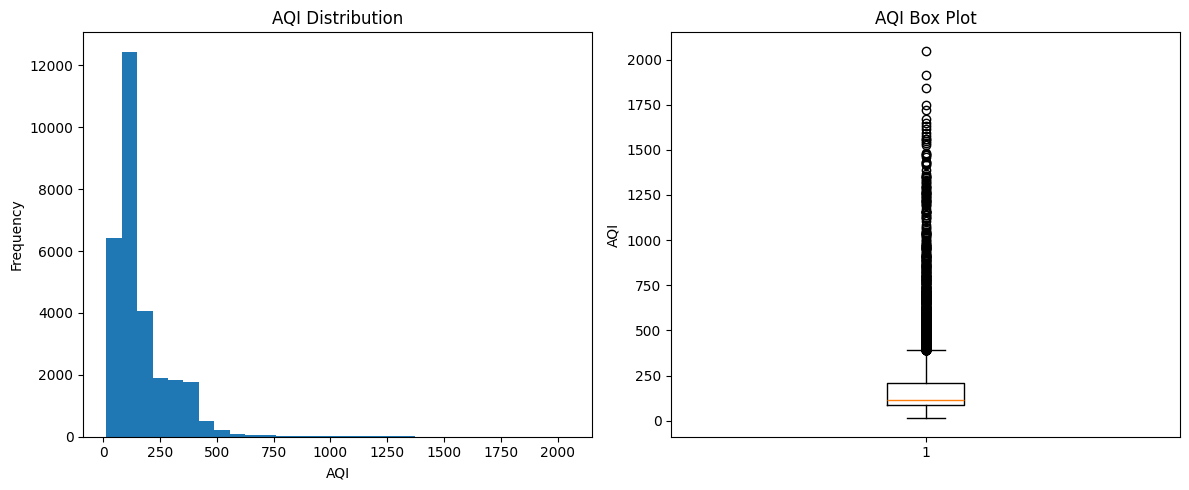

In [55]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(city_clean['AQI'], bins=30)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.boxplot(city_clean['AQI'])
plt.title("AQI Box Plot")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

The histogram shows that most AQI values are concentrated between about 50 and 250, meaning most cities experience moderate to poor air quality.
The box plot reveals a large number of extreme outliers, with some AQI values exceeding 1000 and even 2000. These unusually high values can increase the average AQI suggesting that the mean may overstate the pollution level of a typical city. A histogram was chosen because it shows where AQI values are clustered and helps determine whether most cities fall into a particular pollution range. A box plot was chosen because it highlights extreme values and outliers.

<b>Task 5</b>

In [56]:
q1 = city_clean['AQI'].quantile(0.25)
q3 = city_clean['AQI'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = city_clean[
    (city_clean['AQI'] < lower) |
    (city_clean['AQI'] > upper)
]

print("Number of Outliers:", len(outliers))

city_outlier = city_clean.copy()

city_outlier['AQI'] = city_outlier['AQI'].clip(
    lower=lower,
    upper=upper
)

print("Maximum AQI before treatment:", city_clean['AQI'].max())
print("Maximum AQI after treatment :", city_outlier['AQI'].max())

Number of Outliers: 1465
Maximum AQI before treatment: 2049.0
Maximum AQI after treatment : 391.0


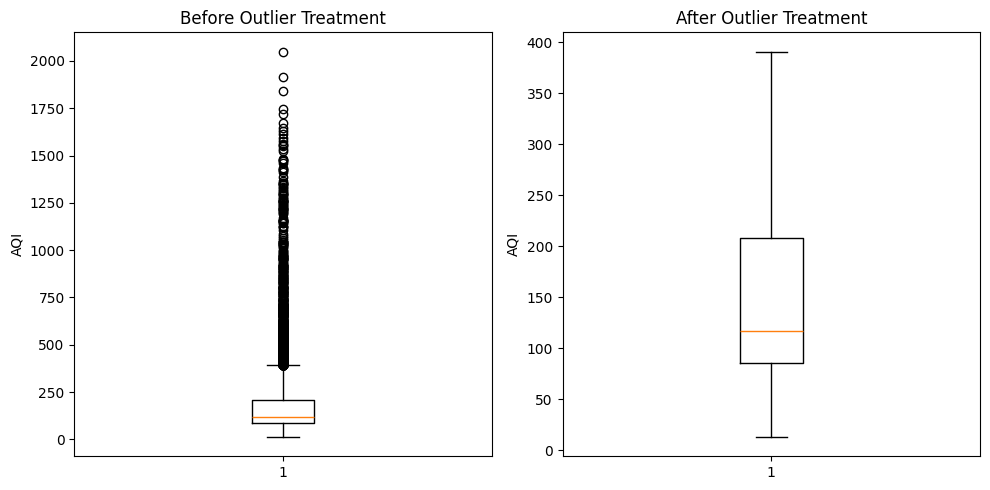

In [57]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(city_clean['AQI'])
plt.title("Before Outlier Treatment")
plt.ylabel("AQI")

plt.subplot(1,2,2)
plt.boxplot(city_outlier['AQI'])
plt.title("After Outlier Treatment")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

The boxplot before treatment shows a large number of extreme AQI values with some observations exceeding 2000. After using IQR method AQI values and capped at IQR upper limit the extreme values were greatly reduced and the maximum AQI dropped to 391.

The method flags any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR as a statistical outlier.<br>
AQI is heavily right-skewed<br>
IQR is robust to the very outliers it is trying to detect<br> 